# Segmentation 1: find parameters (10 degree mosaicity)

Peaks are segmented frame by frame with a local-maximum labelling (ImageD11
`localmaxlabel`). Each frame is first scaled so that `norm_factor` maps to the
top of the uint16 range, and pixels at or below `threshold` (in those uint16
units) are ignored. This notebook shows a frame and the peaks found on it, and
saves the parameters for `02_segment.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from simtools import io, paths, plot, segmenter

plot.dark()


def show(frame):
    """log10(I + 1), max-filtered so that peaks of a few pixels stay visible when the
    2048 x 2048 frame is shrunk to screen size (display only)."""
    return maximum_filter(np.log10(frame + 1), size=9)

In [2]:
SAMPLE = "domains_mosaicity_10p0deg"

## The data
One file per translation (dty), each with 360 sparse frames over omega = 0..179.5 deg.

In [3]:
files = io.scan_files(SAMPLE)
meta = io.read_metadata(SAMPLE)
print(f"{len(files)} translations")
meta

103 translations


{'wavelength_A': 0.24796839748400004,
 'distance_um': 126763.64438847208,
 'pixelsize_um': 75.0,
 'detector_shape': (2048, 2048),
 'omega_step_deg': 0.5,
 'reference_cell': array([ 4.0493,  4.0493,  4.0493, 90.    , 90.    , 90.    ]),
 'space_group': 'Fm-3m'}

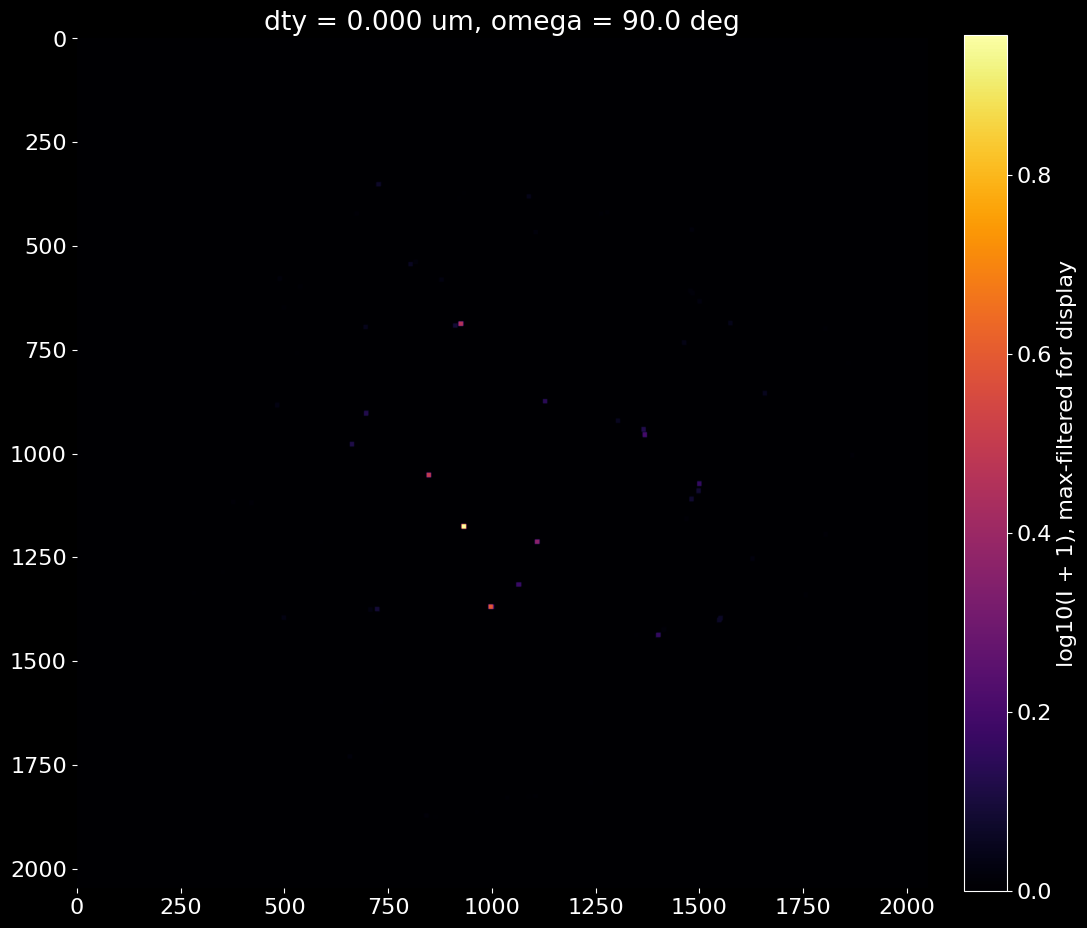

In [4]:
i_trans = len(files) // 2
i_omega = 180
with io.SparseScan(files[i_trans]) as scan:
    frame = scan.frame(i_omega)
    omega, dty = scan.omega[i_omega], scan.dty

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
im = ax.imshow(show(frame), cmap="inferno")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="log10(I + 1), max-filtered for display")
ax.set_title(f"dty = {dty:.3f} um, omega = {omega:.1f} deg")
plot.despine(ax)
plt.show()

## Intensity normalisation

The frames are converted to uint16 before segmentation. A natural choice of
`norm_factor` is the largest pixel value in the data, estimated from random
frames. Pixels near eta = 0 and 180 deg are excluded, because the Lorentz factor
diverges there.

In [5]:
rng = np.random.default_rng(0)
nframes_per_dty = 8
n_dty = 10

X, Y = np.meshgrid(np.arange(frame.shape[1]) - frame.shape[1] // 2,
                   np.arange(frame.shape[0]) - frame.shape[0] // 2)
eta = np.degrees(np.arctan2(X, Y))
roi = (np.abs(eta) > 10) & (np.abs(eta) < 170)

max_intensity = []
for i in rng.choice(np.arange(2, len(files) - 2), n_dty, replace=False):
    with io.SparseScan(files[i]) as scan:
        for j in rng.choice(scan.n_omega, nframes_per_dty, replace=False):
            max_intensity.append(scan.frame(j)[roi].max())
print(f"max intensity over {len(max_intensity)} random frames: {np.max(max_intensity):.1f}")

max intensity over 80 random frames: 35.5


## Chosen parameters

These are the parameters behind the adaptive basis used in the article.
`norm_factor` does not need to equal the estimate above. It sets the intensity scale of the
uint16 frames, and with it how many local maxima rise above `threshold`.

In [6]:
options = {
    "norm_factor": 45,  # intensity mapped to 65535 in the uint16 conversion
    "threshold": 0,  # pixels <= threshold (uint16 units) are not part of any peak
}

197 peaks in the frame


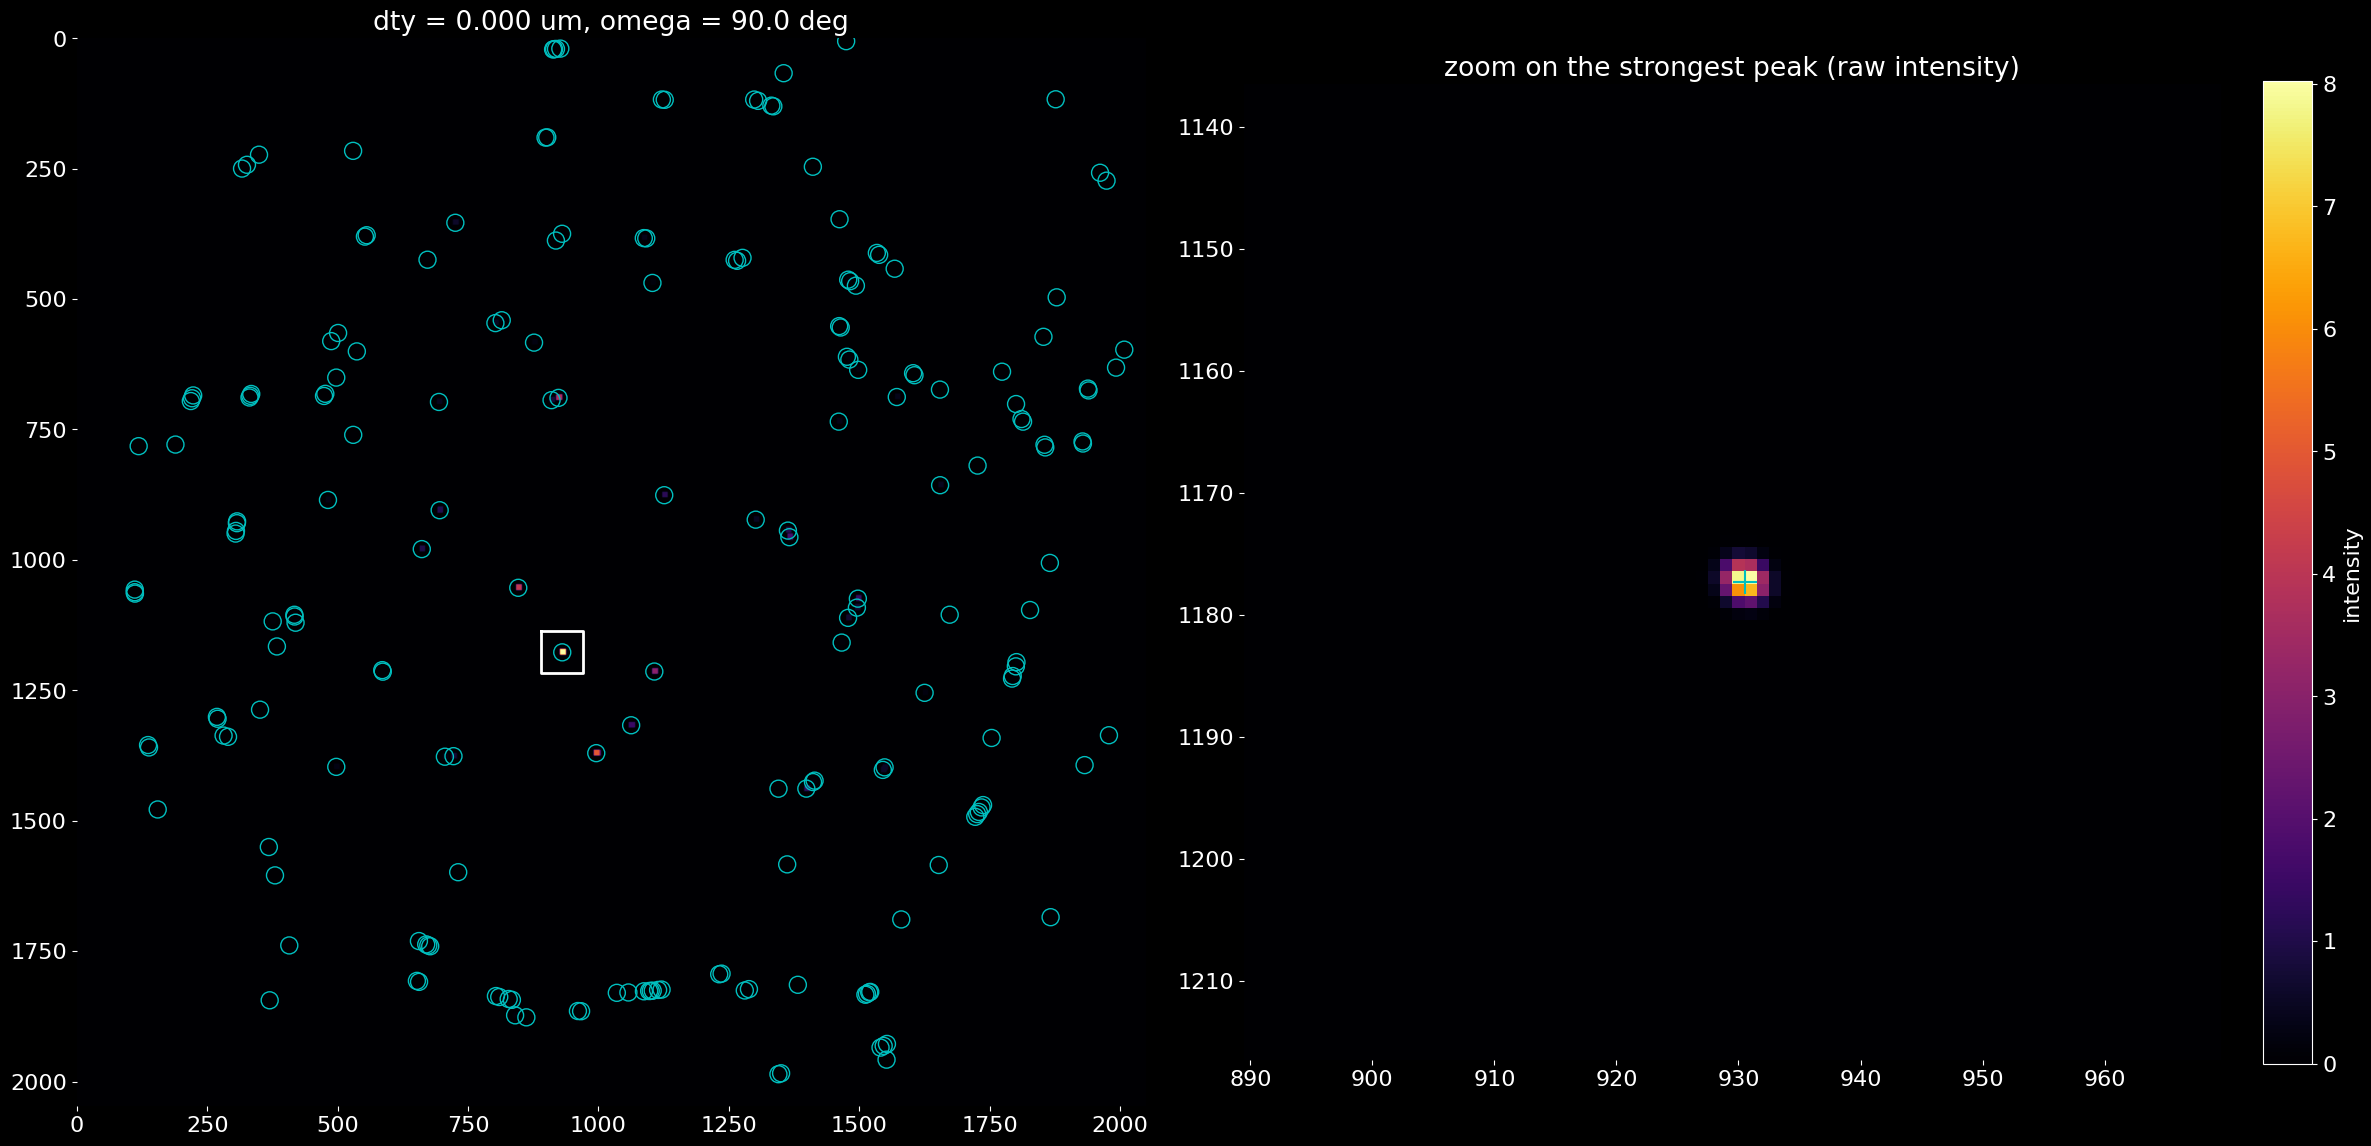

In [7]:
fc, sc, sum_intensity, npix = segmenter.segment_frame(frame, options)
print(f"{len(fc)} peaks in the frame")

# zoom on the strongest peak
k = np.argmax(sum_intensity)
r0, c0 = int(sc[k]), int(fc[k])
half = 40
roi_box = (r0 - half, r0 + half, c0 - half, c0 + half)  # row min, row max, col min, col max

fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(show(frame), cmap="inferno")
ax[0].scatter(fc, sc, marker="o", facecolors="none", edgecolors="c", s=150)
ax[0].plot([roi_box[2], roi_box[2], roi_box[3], roi_box[3], roi_box[2]],
           [roi_box[0], roi_box[1], roi_box[1], roi_box[0], roi_box[0]], c="w", lw=2)
ax[0].set_title(f"dty = {dty:.3f} um, omega = {omega:.1f} deg")

zoom = frame[roi_box[0]:roi_box[1], roi_box[2]:roi_box[3]]
extent = (roi_box[2] - 0.5, roi_box[3] - 0.5, roi_box[1] - 0.5, roi_box[0] - 0.5)
im = ax[1].imshow(zoom, cmap="inferno", extent=extent)
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04, label="intensity")
m = (sc > roi_box[0]) & (sc < roi_box[1]) & (fc > roi_box[2]) & (fc < roi_box[3])
ax[1].scatter(fc[m], sc[m], marker="+", c="c", s=300)
ax[1].set_title("zoom on the strongest peak (raw intensity)")
plot.despine(ax)
plt.tight_layout()
plt.show()

In [8]:
with open(paths.segmenter_options_path(SAMPLE), "w") as f:
    json.dump(options, f, indent=2)
print("saved", paths.segmenter_options_path(SAMPLE))

saved /dtu-compute/msaca/adaptive_basis_simulations/adaptive_basis/domains_mosaicity_10p0deg/segment_peaks/segmenter_options.json
